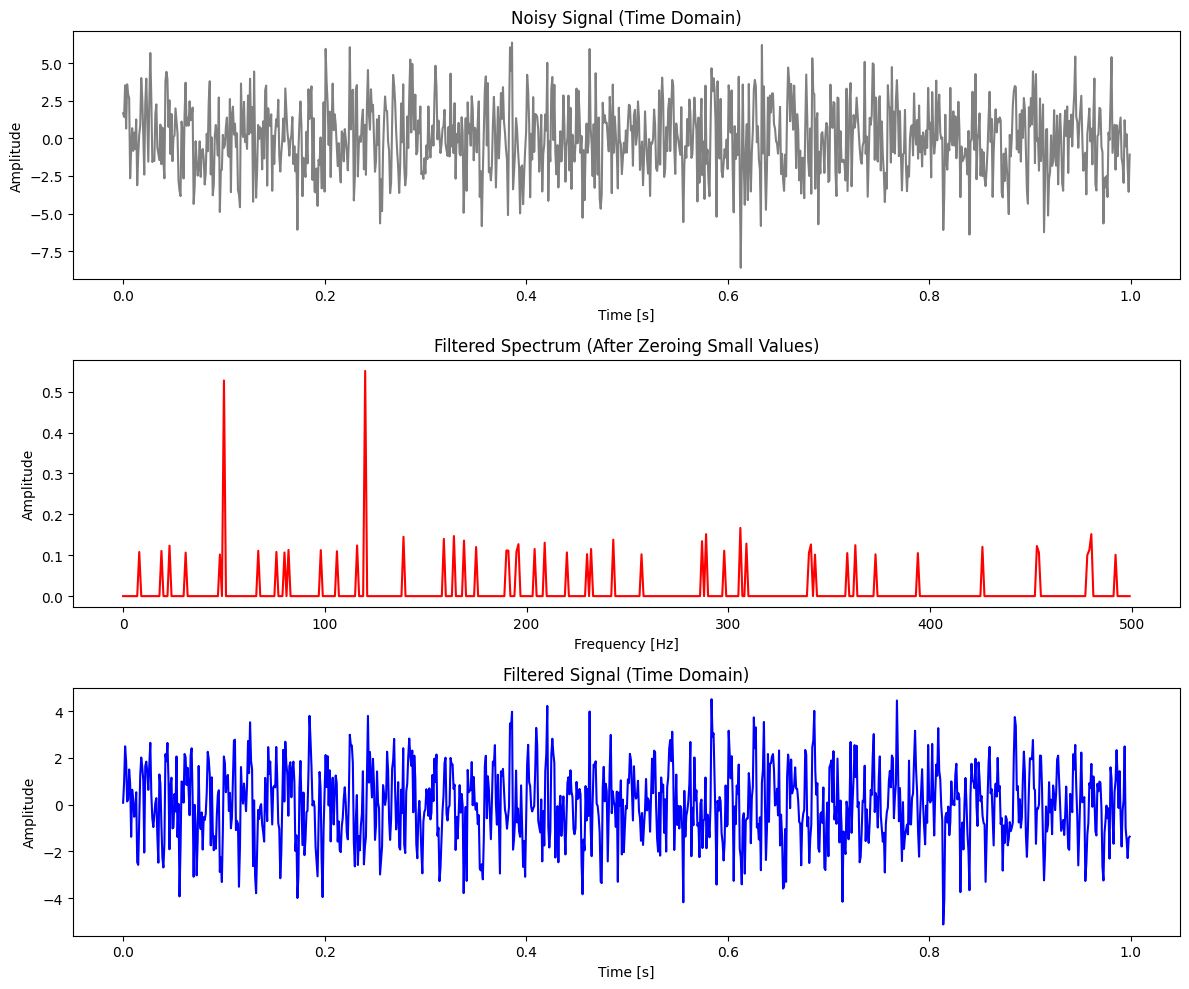

In [1]:
# Exercise 2: Simple Noise Filtering

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate the noisy signal (same as before)
Fs = 1000  # Sampling frequency
T = 1/Fs
t = np.arange(0, 1, T)
signal = np.sin(2*np.pi*50*t) + np.sin(2*np.pi*120*t)
noisy_signal = signal + 2 * np.random.randn(len(t))

# Step 2: Take the FFT of the noisy signal
n = len(noisy_signal)
f = np.fft.fftfreq(n, T)
fft_values = np.fft.fft(noisy_signal)

# Step 3: Zero out small magnitude values to remove noise
magnitude = np.abs(fft_values)
threshold = 100  # You can adjust this threshold
filtered_fft = np.where(magnitude > threshold, fft_values, 0)

# Step 4: Apply the Inverse FFT
filtered_signal = np.fft.ifft(filtered_fft)

# Step 5: Plot the results
plt.figure(figsize=(12, 10))

# Original noisy signal
plt.subplot(3, 1, 1)
plt.plot(t, noisy_signal, color='gray')
plt.title('Noisy Signal (Time Domain)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

# Filtered FFT (Frequency domain)
plt.subplot(3, 1, 2)
plt.plot(f[:n//2], np.abs(filtered_fft)[:n//2] * 1/n, color='red')
plt.title('Filtered Spectrum (After Zeroing Small Values)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')

# Cleaned signal (After inverse FFT)
plt.subplot(3, 1, 3)
plt.plot(t, filtered_signal.real, color='blue')
plt.title('Filtered Signal (Time Domain)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()
